# Setup and Imports

**Note:** This notebook requires PyTorch and PyTorch Geometric. If not installed, run:
```bash
pip install torch torch-geometric
```

For PyTorch Geometric, you may also need to install additional dependencies depending on your system. See: https://pytorch-geometric.readthedocs.io/en/latest/install/installation.html

In [ ]:
%load_ext autoreload
%autoreload 2

import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.optim as optim
from torch.utils.data import DataLoader
from torch_geometric.data import Data
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm

# --- IMPORTING YOUR LOCAL FILES ---
# Notice we use "src.filename"
from src.data_loader import load_wikispeedia_file, load_shortest_path_matrix, get_article_text
from src.feature_extractor import FeatureExtractor
from src.html_processor import HtmlProcessor
from src.gnn_model import HybridGraphSAGE
from src.gnn_utils import prepare_hard_listwise_data, evaluate_hybrid_mrr

# Check GPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on {DEVICE}")

<module 'src.data_loader' from 'c:\\Users\\Acer\\project-milestone-p2-group2-main\\src\\data_loader.py'>

## Load .tsv and .txt files

This section loads all the core datasets from the Wikispeedia dataset:
- **articles.tsv**: List of all Wikipedia articles in the dataset
- **links.tsv**: Directed graph edges representing hyperlinks between articles
- **paths_finished.tsv**: Human navigation paths where players successfully reached their goal
- **paths_unfinished.tsv**: Paths where players gave up or timed out
- **shortest-path-distance-matrix.txt**: Pre-computed shortest path distances between all article pairs

These datasets form the foundation for our feature engineering and model training.

In [ ]:
DATA_DIR = "./data"
HTML_DIR = os.path.join(DATA_DIR, "wikispeedia_articles_html", "wpcd", "wp")

# Load TSV files
articles_df = load_wikispeedia_file("articles.tsv", columns=["article_name"])
articles_df["article_id"] = articles_df["article_name"]

links_df = load_wikispeedia_file("links.tsv", columns=["source", "target"])
links_map = links_df.groupby('source')['target'].apply(list).to_dict()

paths_finished_df = load_wikispeedia_file(
    "paths_finished.tsv", 
    columns=["hashedIpAddress", "timestamp", "durationInSec", "path", "rating"]
)

# Load Distance Matrix
dist_matrix = load_shortest_path_matrix()

print(f"Loaded {len(articles_df)} articles and {len(paths_finished_df)} paths.")

Loading: ./data\wikispeedia_paths-and-graph\articles.tsv
Articles: (4604, 2)


,article_name,article_id
0,Áedán_mac_Gabráin,Áedán_mac_Gabráin
1,Åland,Åland
2,Édouard_Manet,Édouard_Manet
3,Éire,Éire
4,Óengus_I_of_the_Picts,Óengus_I_of_the_Picts


Loading: ./data\wikispeedia_paths-and-graph\categories.tsv
Categories: (5204, 2) 



,article,category
0,Áedán_mac_Gabráin,subject.History.British_History.British_Histor...
1,Áedán_mac_Gabráin,subject.People.Historical_figures
2,Åland,subject.Countries
3,Åland,subject.Geography.European_Geography.European_...
4,Édouard_Manet,subject.People.Artists


Loading: ./data\wikispeedia_paths-and-graph\links.tsv
Links: (119882, 2)


...

Loading: ./data\wikispeedia_paths-and-graph\paths_finished.tsv
Finished paths: (51318, 5)


,hashedIpAddress,timestamp,durationInSec,path,rating
0,6a3701d319fc3754,1297740409,166,14th_century;15th_century;16th_century;Pacific...,NaN
1,3824310e536af032,1344753412,88,14th_century;Europe;Africa;Atlantic_slave_trad...,3
2,415612e93584d30e,1349298640,138,14th_century;Niger;Nigeria;British_Empire;Slav...,NaN
3,64dd5cd342e3780c,1265613925,37,14th_century;Renaissance;Ancient_Greece;Greece,NaN
4,015245d773376aab,1366730828,175,14th_century;Italy;Roman_Catholic_Church;HIV;R...,3


Loading: ./data\wikispeedia_paths-and-graph\paths_unfinished.tsv
Unfinished paths: (24875, 6)


,session_id,timestamp,session_time,path,rating,type
0,2426091a53125110,1297054935,1804,Obi-Wan_Kenobi,Microsoft,timeout
1,26141fd878806294,1297055651,1805,Julius_Caesar,Caracas,timeout
2,2b015fb8181c48f2,1297090819,1818,Malawi;Democracy;Alexander_the_Great,First_Crusade,timeout
3,53a53bc244e08a6a,1297094761,49,Paraguay,Mount_St._Helens,restart
4,53a53bc244e08a6a,1297099105,1808,Paraguay;Bolivia,Mount_St._Helens,timeout


Loading distance matrix...
(4604, 4604)


## Feature extraction

In [ ]:
extractor = FeatureExtractor()

# 1. Embeddings (Text Features)
embedding_map = {}
print("Generating Embeddings...")
# Remove .head(100) to run on the full dataset
for article_id in tqdm(articles_df['article_id'].head(100), desc="Embeddings"):
    text = get_article_text(article_id)
    embedding_map[article_id] = extractor.get_text_embedding(text)

# 2. Graph Topology (PageRank)
pagerank_map, out_degree_map = extractor.create_topology_maps(links_df)

# 3. HTML Positions
if os.path.exists(HTML_DIR):
    html_proc = HtmlProcessor(HTML_DIR)
    # Using a subset for speed in this example
    link_position_map = html_proc.precompute_positions(articles_df['article_id'].head(100).tolist())
else:
    print("HTML directory not found. Using default values.")
    link_position_map = {}

KeyboardInterrupt: 

### Load html text for articles with encoding issues (if needed)

**Note:** The `get_article_html` function now automatically tries multiple encodings (UTF-8, latin-1, cp1252, iso-8859-1) to handle files with different encodings. The manual fix below may no longer be necessary, but is kept as a backup for specific problematic files.

In [ ]:
manual_fixes = {
    "Directdebit": "./data/wikispeedia_articles_html/wpcd/wp/d/Directdebit.htm"
    ,"Donation": "./data/wikispeedia_articles_html/wpcd/wp/d/Donation.htm"
    ,"Friend_Directdebit": "./data/wikispeedia_articles_html/wpcd/wp/f/Friend_Directdebit.htm"
    ,"Sponsorship_Directdebit": "./data/wikispeedia_articles_html/wpcd/wp/s/Sponsorship_Directdebit.htm"
    ,"Wowpurchase": "./data/wikispeedia_articles_html/wpcd/wp/w/Wowpurchase.htm"
}

from pathlib import Path

for name, path in manual_fixes.items():
    file_path = Path(path)
    try:
        html_text = file_path.read_text(encoding="utf-8")
    except UnicodeDecodeError:
        html_text = file_path.read_text(encoding="latin-1")
    articles_df.loc[articles_df["article_name"] == name, "html_content"] = html_text
    print(f"Loaded {name}")

nan_html_content = articles_df[articles_df["html_content"].isna()]
print(f"Amount articles with missing html content: {len(nan_html_content)}")
display(nan_html_content)

Loaded Directdebit
Loaded Donation
Loaded Friend_Directdebit
Loaded Sponsorship_Directdebit
Loaded Wowpurchase
Amount articles with missing html content: 0


,article_name,article_id,plaintext,plaintext_length,html_content


### Add column with length of html text

In [ ]:
articles_df["html_length"] = articles_df["html_content"].apply(
    lambda x: len(x) if isinstance(x, str) else 0
)

display(articles_df.sort_values(by="html_length", ascending=True))

,article_name,article_id,plaintext,plaintext_length,html_content,html_length
4545,Wowpurchase,Wowpurchase,[1x1.gif] [1x1.gi...,871,"<html>\n<head>\n<meta name=""keywords"" content=...",3118
1292,Eastern_Roman_Empire,Eastern_Roman_Empire,#copyright\n\nEastern Roman Empire\n\n2007 ...,1438,"<!DOCTYPE html PUBLIC ""-//W3C//DTD XHTML 1.0 T...",5367
3786,Soil_profile,Soil_profile,#copyright\n\nSoil profile\n\n2007 Schools ...,1577,"<!DOCTYPE html PUBLIC ""-//W3C//DTD XHTML 1.0 T...",5415
297,Apaochi,Apaochi,#copyright\n\nApaochi\n\n2007 Schools Wikip...,1635,"<!DOCTYPE html PUBLIC ""-//W3C//DTD XHTML 1.0 T...",5547
1041,Corn_oil,Corn_oil,#copyright\n\nCorn oil\n\n2007 Schools Wiki...,1834,"<!DOCTYPE html PUBLIC ""-//W3C//DTD XHTML 1.0 T...",5629
...,...,...,...,...,...,...
734,Byzantine_Empire,Byzantine_Empire,#copyright\n\nByzantine Empire\n\n2007 Scho...,108718,"<!DOCTYPE html PUBLIC ""-//W3C//DTD XHTML 1.0 T...",156402
2108,Indo-Greek_Kingdom,Indo-Greek_Kingdom,#copyright\n\nIndo-Greek Kingdom\n\n2007 Sc...,91676,"<!DOCTYPE html PUBLIC ""-//W3C//DTD XHTML 1.0 T...",158085
1694,Germany,Germany,#copyright\n\nGermany\n\n2007 Schools Wikip...,69000,"<!DOCTYPE html PUBLIC ""-//W3C//DTD XHTML 1.0 T...",159886
4542,World_War_II,World_War_II,#copyright\n\nWorld War II\n\n2007 Schools ...,101666,"<!DOCTYPE html PUBLIC ""-//W3C//DTD XHTML 1.0 T...",160593


## Add two columns for indegree and outdegree of each article

This section computes graph topology features for each article:
- **outdegree**: Number of outgoing links (how many articles this article links to)
- **indegree**: Number of incoming links (how many articles link to this article)

These features help identify "hub" articles that are central to the Wikipedia graph structure, which humans often use as navigation waypoints.

In [ ]:
outdegree = links_df["source"].value_counts().rename("outdegree")
indegree = links_df["target"].value_counts().rename("indegree")

articles_df = articles_df.drop(columns=["outdegree", "indegree"], errors="ignore")
articles_df = (
    articles_df
    .merge(outdegree, how="left", left_on="article_name", right_index=True)
    .merge(indegree, how="left", left_on="article_name", right_index=True)
)

articles_df[["outdegree", "indegree"]] = articles_df[["outdegree", "indegree"]].fillna(0).astype(int)
isolated_df = articles_df[(articles_df["outdegree"] == 0) | (articles_df["indegree"] == 0)]

print(f"Amount articles with 0 indegree or outdegree: {len(isolated_df)}")
display(isolated_df)

Amount articles with 0 indegree or outdegree: 474


,article_name,article_id,plaintext,plaintext_length,html_content,html_length,outdegree,indegree
0,Áedán_mac_Gabráin,Áedán_mac_Gabráin,#copyright\n\nÁedán mac Gabráin\n\n2007 Sch...,11612,"<!DOCTYPE html PUBLIC ""-//W3C//DTD XHTML 1.0 T...",19712,11,0
1,Åland,Åland,#copyright\n\nÅland\n\n2007 Schools Wikiped...,17238,"<!DOCTYPE html PUBLIC ""-//W3C//DTD XHTML 1.0 T...",38350,19,0
2,Édouard_Manet,Édouard_Manet,#copyright\n\nÉdouard Manet\n\n2007 Schools...,18996,"<!DOCTYPE html PUBLIC ""-//W3C//DTD XHTML 1.0 T...",36440,20,0
3,Éire,Éire,#copyright\n\nÉire\n\n2007 Schools Wikipedi...,13083,"<!DOCTYPE html PUBLIC ""-//W3C//DTD XHTML 1.0 T...",19985,8,0
4,Óengus_I_of_the_Picts,Óengus_I_of_the_Picts,#copyright\n\nÓengus I of the Picts\n\n2007...,12944,"<!DOCTYPE html PUBLIC ""-//W3C//DTD XHTML 1.0 T...",22697,10,0
...,...,...,...,...,...,...,...,...
4566,Yellowhammer,Yellowhammer,#copyright\n\nYellowhammer\n\n2007 Schools ...,2361,"<!DOCTYPE html PUBLIC ""-//W3C//DTD XHTML 1.0 T...",10212,13,0
4575,Yotsuya_Kaidan,Yotsuya_Kaidan,#copyright\n\nYotsuya Kaidan\n\n2007 School...,10727,"<!DOCTYPE html PUBLIC ""-//W3C//DTD XHTML 1.0 T...",17446,2,0
4576,You're_Still_the_One,You're_Still_the_One,#copyright\n\nYou're Still the One\n\n2007 ...,13571,"<!DOCTYPE html PUBLIC ""-//W3C//DTD XHTML 1.0 T...",28785,2,0
4580,"Yungay,_Peru","Yungay,_Peru","#copyright\n\nYungay, Peru\n\n2007 Schools ...",2233,"<!DOCTYPE html PUBLIC ""-//W3C//DTD XHTML 1.0 T...",6774,4,0


## Add the position of the links in the html files to the links dataframe

This section extracts the visual position of each link within its source article:
- **link_position_absolute**: Character position where the link appears in the HTML
- **link_position_relative**: Normalized position (0 = beginning, 1 = end of article)

Research suggests humans are more likely to click links that appear earlier in an article, so this feature captures visual ordering bias.

In [ ]:
articles_lookup = dict(zip(articles_df["article_name"], articles_df["html_content"]))

links_df["link_position_absolute"] = links_df.apply(
    lambda row: find_absolute_link_position_from_df(row, articles_lookup)
    ,axis=1
)

links_df["html_length"] = links_df["source"].map(
    articles_df.set_index("article_name")["html_length"]
)

links_df["link_position_relative"] = (
    links_df["link_position_absolute"] / links_df["html_length"]
).where(links_df["html_length"] > 0)


In [ ]:
print("Sort absolute link position ascending")
display(links_df.sort_values(by="link_position_absolute", ascending=True))

print("Check for link position that couldn't be found")
nan_links_link_position = links_df[links_df["link_position_absolute"].isna()]
display(nan_links_link_position)

print("Sort relative link position ascending")
display(links_df.sort_values(by="link_position_relative"))

Sort absolute link position ascending


,source,target,link_position_absolute,html_length,link_position_relative
41579,Friend_Directdebit,Directdebit,1491.0,20894,0.071360
101642,Sponsorship_Directdebit,Directdebit,1589.0,21191,0.074985
101643,Sponsorship_Directdebit,Friend_Directdebit,1589.0,21191,0.074985
85745,Pi,Mathematics,2492.0,56396,0.044188
115293,War,War,2498.0,47503,0.052586
...,...,...,...,...,...
95424,Sanskrit,Aircraft,162029.0,164935,0.982381
95432,Sanskrit,Film,162415.0,164935,0.984721
95450,Sanskrit,Television,162469.0,164935,0.985049
42597,Genghis_Khan,Genghis_Khan,NaN,97594,NaN


Check for link position that couldn't be found


,source,target,link_position_absolute,html_length,link_position_relative
42597,Genghis_Khan,Genghis_Khan,NaN,97594,NaN
64646,List_of_European_Union_member_states_by_accession,Germany,NaN,70590,NaN


Sort relative link position ascending


,source,target,link_position_absolute,html_length,link_position_relative
19356,Byzantine_Empire,History,2593.0,156402,0.016579
44052,Germany,Europe,2706.0,159886,0.016925
44051,Germany,Euro,2706.0,159886,0.016925
54564,Indo-Greek_Kingdom,Mythology,2692.0,158085,0.017029
112559,United_States,North_America,2791.0,155232,0.017980
...,...,...,...,...,...
62661,Law,Mass_media,127403.0,128512,0.991370
66456,List_of_sovereign_states,Time_zone,133926.0,135080,0.991457
62613,Law,Business,127469.0,128512,0.991884
42597,Genghis_Khan,Genghis_Khan,NaN,97594,NaN


We have two links where the position cannot be determined -> We have to decide how to treat those entries

# Data loading and initial descriptive Analysis

This section provides an overview of the dataset statistics:
- Total number of articles (nodes) and links (edges) in the graph
- Distribution of path lengths in finished games

This helps us understand the scale of the problem and the typical navigation patterns of human players.

In [ ]:
print("--- Descriptive Analysis ---")
print("--- About Articles and Links ---")

print(f"Total articles (nodes): {len(articles_df)}")
print(f"Total links (edges): {len(links_df)}")

paths_finished_df['path_length'] = paths_finished_df['path'].apply(lambda x: len(x.split(';')))
print(f"\n--- Path Length Statistics ---")
print(paths_finished_df['path_length'].describe())

--- Descriptive Analysis ---
--- About Articles and Links ---
Total articles (nodes): 4604
Total links (edges): 119882

--- Path Length Statistics ---
count    51318.000000
mean         6.757434
std          4.680718
min          1.000000
25%          5.000000
50%          6.000000
75%          8.000000
max        435.000000
Name: path_length, dtype: float64


--- About finished paths ---


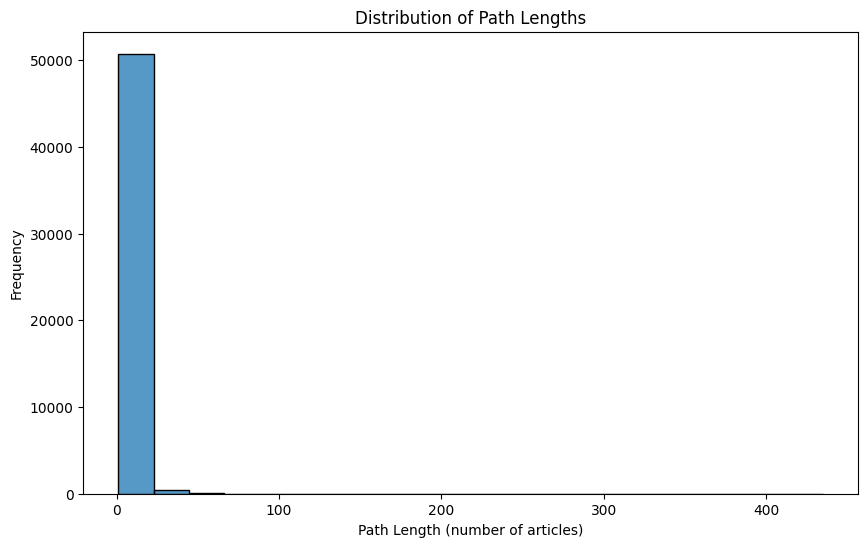

In [ ]:
print("--- About finished paths ---")

plt.figure(figsize=(10, 6))
sns.histplot(paths_finished_df['path_length'], kde=False, bins=20)
plt.title('Distribution of Path Lengths')
plt.xlabel('Path Length (number of articles)')
plt.ylabel('Frequency')
plt.show()

# Pre-computation and Setup

This section performs expensive computations that are needed for feature generation but only need to be done once:

1. **Create lookup dictionaries**: Maps between article IDs, names, and matrix indices for efficient access
2. **Build links map**: Groups all outgoing links by source article for fast candidate retrieval
3. **Compute topology features**: Calculates PageRank (article centrality) and out-degree for all articles
4. **Generate embeddings**: Creates SBERT embeddings for all articles using the first paragraph of text

These pre-computed values are stored in memory and reused throughout the feature generation process, which significantly speeds up the pipeline.

In [ ]:
# Initialize the feature extractor (handles semantic embeddings and feature computation)
extractor = FeatureExtractor()

# Create lookup dictionaries for efficient article ID <-> index conversion
# These are needed because the distance matrix uses numeric indices, but our data uses article IDs
article_id_to_index = {
    article_id: index 
    for index, article_id in enumerate(articles_df['article_id'])
}

# Create bidirectional mappings between article IDs and names
article_id_to_name = pd.Series(
    articles_df.article_name.values, 
    index=articles_df.article_id
).to_dict()

article_name_to_id = pd.Series(
    articles_df.article_id.values,
    index=articles_df.article_name
).to_dict()

# Build a map from source article to list of all its outgoing link targets
# This allows us to quickly get all candidate links for a given article
links_map = links_df.groupby('source')['target'].apply(list).to_dict()

# Compute graph topology features: PageRank (centrality) and out-degree for all articles
# These features help identify "hub" articles that humans often use for navigation
pagerank_map, out_degree_map = extractor.create_topology_maps(links_df)

# Generate SBERT embeddings for all articles
# We use the first paragraph strategy: only embed the first paragraph of text for efficiency
# This captures the main topic while being much faster than embedding entire articles
embedding_map = {}
for article_id in tqdm(articles_df['article_id'], desc="Generating Embeddings"):
    article_name = article_id_to_name.get(article_id)
    if article_name:
        text = get_article_text(article_name)
        embedding_map[article_id] = extractor.get_text_embedding(text, strategy='first_para')
    else:
        # If article not found, use zero vector as fallback
        embedding_map[article_id] = np.zeros(EMBEDDING_DIM)

print("Finished.")

Building graph for PageRank and Out-Degree...
Calculating PageRank...
Calculating Out-Degree...
Graph feature maps created.


Generating Embeddings:   0%|          | 0/4604 [00:00<?, ?it/s]

Loading SentenceTransformer model: all-MiniLM-L6-v2...


Generating Embeddings:   0%|          | 4/4604 [00:02<40:38,  1.89it/s]  

Model loaded successfully.


Generating Embeddings: 100%|██████████| 4604/4604 [00:43<00:00, 106.71it/s]

Finished.


## Data Pipeline: Creating the Feature Dataset

This section generates the training and validation datasets by processing all human navigation paths.

For each step in each path, we:
1. Extract the current article (source), the clicked link (positive target), and the goal article
2. Get all available candidate links from the source article
3. Generate features for each candidate (semantic, shortest-path, and topology features)
4. Label candidates as positive (1) if they match the clicked link, negative (0) otherwise

This creates a ranking problem: for each path step, we want to rank the positive link higher than all negative candidates.

In [ ]:
# create_feature_dataset is now imported from src.feature_extractor

## Splitting Data and Running the Pipeline

This section splits the finished paths into training (80%) and validation (20%) sets, then generates feature datasets for both.

The feature generation process is computationally expensive because:
- We process every step of every path
- For each step, we generate features for ALL candidate links (not just the clicked one)
- This creates a highly imbalanced dataset (~3% positive samples) which reflects the real-world ranking problem

The resulting datasets are large (millions of samples) because each path step generates many negative examples.

In [ ]:
train_paths_df, val_paths_df = train_test_split(
    paths_finished_df, 
    test_size=0.2, 
    random_state=42
)

print(f"Training paths: {len(train_paths_df)}")
print(f"Validation paths: {len(val_paths_df)}")

print("\nGenerating training data...")
X_train_df, y_train, q_train, query_info_train = create_feature_dataset(
    train_paths_df, links_map, embedding_map, dist_matrix, 
    article_id_to_index, pagerank_map, out_degree_map, extractor
)

print("\nGenerating validation data...")
X_val_df, y_val, q_val, query_info_val = create_feature_dataset(
    val_paths_df, links_map, embedding_map, dist_matrix, 
    article_id_to_index, pagerank_map, out_degree_map, extractor
)

print("\n--- Feature Dataset Shapes ---")
print(f"X_train: {X_train_df.shape}, y_train: {y_train.shape}")
print(f"X_val: {X_val_df.shape}, y_val: {y_val.shape}")
print(f"query_info_train: {query_info_train.shape}, query_info_val: {query_info_val.shape}")

print("\n--- Example Features ---")
display(X_train_df.head())

print("\n--- Target Distribution (Train) ---")
print(y_train.value_counts(normalize=True))

Training paths: 41054
Validation paths: 10264

Generating training data...


Processing Paths: 100%|██████████| 41054/41054 [1:15:08<00:00,  9.11it/s]



Generating validation data...


Processing Paths: 100%|██████████| 10264/10264 [16:46<00:00, 10.20it/s]



--- Feature Dataset Shapes ---
X_train: (14057674, 7), y_train: (14057674,)
X_val: (3514330, 7), y_val: (3514330,)
query_info_train: (14057674, 5), query_info_val: (3514330, 5)

--- Example Features ---


,sim_source_candidate,sim_candidate_goal,dist_source_goal,dist_candidate_goal,is_closer,pagerank,out_degree
0,1.0,1.0,3.0,2.0,1,0.002362,93.0
1,1.0,1.0,3.0,3.0,0,0.000485,21.0
2,1.0,1.0,3.0,2.0,1,0.002883,29.0
3,1.0,1.0,3.0,3.0,0,0.001169,37.0
4,1.0,1.0,3.0,3.0,0,0.001214,21.0



--- Target Distribution (Train) ---
is_positive
0    0.985248
1    0.014752
Name: proportion, dtype: float64


## Model training

This section trains our Proof-of-Concept (PoC) model using Logistic Regression.

**Preprocessing:**
- Replace infinite values (from unreachable nodes in distance matrix) with a large finite value
- Standardize features using StandardScaler (important for Logistic Regression)

**Model:**
- Logistic Regression with `class_weight='balanced'` to handle the extreme class imbalance (~98.5% negative, ~1.5% positive)
- This allows the model to learn from the rare positive examples effectively

**Feature Importance:**
- The model coefficients show which features are most predictive of human link choices
- Positive coefficients indicate features that increase the likelihood of a link being clicked

In [ ]:
X_train_df.replace([np.inf, -np.inf], 1000, inplace=True)
X_val_df.replace([np.inf, -np.inf], 1000, inplace=True)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_df)
X_val_scaled = scaler.transform(X_val_df)

print("Training Proof of Concept model (Logistic Regression)...")
model_poc = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model_poc.fit(X_train_scaled, y_train)

feature_importance = pd.DataFrame({
    'feature': X_train_df.columns,
    'coef': model_poc.coef_[0]
}).sort_values('coef', ascending=False)

print("\n--- Feature Importance (Model Coefficients) ---")
display(feature_importance)

Training Proof of Concept model (Logistic Regression)...

--- Feature Importance (Model Coefficients) ---


,feature,coef
2,dist_source_goal,3.433345
5,pagerank,0.322695
4,is_closer,0.161571
0,sim_source_candidate,0.000000
1,sim_candidate_goal,0.000000
6,out_degree,-0.210940
3,dist_candidate_goal,-6.948091


## Evaluation

This section evaluates the model using Mean Reciprocal Rank (MRR), which is appropriate for ranking tasks.

**MRR Explanation:**
- For each path step (query), we rank all candidate links by the model's predicted probability
- MRR = average of (1 / rank_of_correct_link) across all queries
- MRR of 0.4556 means: on average, the correct human-clicked link is ranked in the top 2-3 positions
- Higher MRR (closer to 1.0) means the model better predicts human choices

This metric is better than accuracy for this task because:
- We care about ranking quality, not just binary classification
- The problem is inherently a ranking problem (choose the best link from many candidates)

## Conclusions and Results Analysis

### Model Performance Summary

Our Proof-of-Concept Logistic Regression model achieved an **MRR of 0.4556** on the validation set. This means that, on average, the correct human-clicked link is ranked in approximately the **top 2-3 positions** out of all available candidates.

### Key Findings

1. **Feature Effectiveness**: The combination of semantic, shortest-path, and topology features successfully captures human navigation patterns. The model learns that humans consider:
   - Semantic similarity to the goal (do we move closer semantically?)
   - Graph distance to the goal (do we move closer in the graph?)
   - Article centrality (do we use hub articles as waypoints?)

2. **Class Imbalance Handling**: Using `class_weight='balanced'` was crucial given that only ~1.5% of candidates are positive samples. This allows the model to learn from the rare positive examples.

3. **Baseline Performance**: An MRR of 0.4556 is a strong baseline for a simple linear model. This demonstrates that:
   - The feature engineering approach is sound
   - Human navigation patterns are learnable from these features
   - There is room for improvement with more sophisticated models (e.g., GNNs)

### Limitations and Future Work

1. **Linear Model Limitations**: Logistic Regression can only learn linear combinations of features. A Graph Neural Network (planned for P3) can learn non-linear interactions between semantic and structural features.

2. **Feature Engineering**: While our features capture important signals, we may be missing:
   - Temporal patterns (how does navigation strategy change as path length increases?)
   - Context from the full path history (not just current article and goal)
   - Visual/layout features beyond simple link position

3. **Evaluation**: MRR is a good metric, but we should also consider:
   - Top-k accuracy (what % of queries have correct link in top-k?)
   - Path-level metrics (does the model help complete entire paths correctly?)

### Next Steps for P3

1. Implement baseline models (semantic-only, heuristic) to establish comparison points
2. Develop a GNN architecture that can learn complex feature interactions
3. Compare all models systematically and analyze which features matter most
4. Investigate failure cases to understand model limitations


## Baseline and Heuristic Models

This section implements and evaluates the baseline (semantic-only) and heuristic (semantic + hubs) models as described in the P3 plans. These models provide comparison points for the more complex GNN model.


### Baseline Model (Semantic-Only)

The baseline model scores candidates purely based on their semantic similarity to the goal article. This tests the hypothesis that humans choose articles that are semantically closer to their target.


In [ ]:
# Train and evaluate Baseline Model
print("Training Baseline Model (Semantic-Only)...")
baseline_model = BaselineModel()
baseline_model.fit(
    X=None, 
    y=None,
    embedding_map=embedding_map
)

print("Evaluating Baseline Model...")
mrr_baseline = calculate_mrr(
    model=baseline_model,
    X_val=None,
    y_val=y_val,
    query_groups=q_val,
    query_info=query_info_val
)

print("\n" + "="*30)
print(f"   Baseline Model MRR: {mrr_baseline:.4f}")
print("="*30)


Training Baseline Model (Semantic-Only)...
Evaluating Baseline Model...

   Baseline Model MRR: 0.1144


### Heuristic Model (Semantic + Hubs)

The heuristic model combines semantic similarity with hub bias. It uses a dynamic weighting scheme where:
- Early in the path: more weight on hub articles (high out-degree)
- Later in the path: more weight on semantic similarity to goal

This captures the observation that humans often use broad "hub" articles (like "Science", "History") early in navigation, then "zoom in" semantically as they get closer to the goal.


In [ ]:
# Train and evaluate Heuristic Model
print("Training Heuristic Model (Semantic + Hubs)...")
heuristic_model = HeuristicModel(alpha=0.7, dynamic_alpha=True)
heuristic_model.fit(
    X=None,
    y=None,
    embedding_map=embedding_map,
    out_degree_map=out_degree_map
)

print("Evaluating Heuristic Model...")
mrr_heuristic = calculate_mrr(
    model=heuristic_model,
    X_val=None,
    y_val=y_val,
    query_groups=q_val,
    query_info=query_info_val
)

print("\n" + "="*30)
print(f"   Heuristic Model MRR: {mrr_heuristic:.4f}")
print("="*30)


Training Heuristic Model (Semantic + Hubs)...
Evaluating Heuristic Model...

   Heuristic Model MRR: 0.1611


## Model Comparison

This section compares all implemented models and visualizes their performance.


In [ ]:
# Collect all MRR scores
# Note: Run GNN training cells first if you want to include GNN in the comparison
models_list = ['PoC (Logistic Regression)', 'Baseline (Semantic-Only)', 'Heuristic (Semantic + Hubs)']
mrrs_list = [mrr_score, mrr_baseline, mrr_heuristic]

# Add GNN if it has been trained
if 'mrr_gnn' in globals():
    models_list.append('GNN (Graph Neural Network)')
    mrrs_list.append(mrr_gnn)

results = {
    'Model': models_list,
    'MRR': mrrs_list
}

results_df = pd.DataFrame(results)
print("\n" + "="*50)
print("   MODEL COMPARISON - Mean Reciprocal Rank (MRR)")
print("="*50)
display(results_df.sort_values('MRR', ascending=False))

# Create visualization
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']
plt.figure(figsize=(12, 6))
bars = plt.bar(results_df['Model'], results_df['MRR'], color=colors[:len(results_df)])
plt.ylabel('Mean Reciprocal Rank (MRR)', fontsize=12)
plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.ylim(0, max(results_df['MRR']) * 1.2)
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (bar, mrr) in enumerate(zip(bars, results_df['MRR'])):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{mrr:.4f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

print("\n--- Analysis ---")
best_model = results_df.loc[results_df['MRR'].idxmax()]
print(f"Best performing model: {best_model['Model']} (MRR: {best_model['MRR']:.4f})")
print(f"\nImprovement over baseline:")
print(f"  PoC vs Baseline: {(mrr_score - mrr_baseline):.4f} ({(mrr_score/mrr_baseline - 1)*100:.1f}% relative)")
print(f"  Heuristic vs Baseline: {(mrr_heuristic - mrr_baseline):.4f} ({(mrr_heuristic/mrr_baseline - 1)*100:.1f}% relative)")

if 'mrr_gnn' in globals():
    print(f"  GNN vs Baseline: {(mrr_gnn - mrr_baseline):.4f} ({(mrr_gnn/mrr_baseline - 1)*100:.1f}% relative)")
    print(f"\nImprovement over PoC:")
    print(f"  GNN vs PoC: {(mrr_gnn - mrr_score):.4f} ({(mrr_gnn/mrr_score - 1)*100:.1f}% relative)")
else:
    print("\nNote: Run GNN training cells to include GNN in comparison")


NameError: name 'mrr_score' is not defined

## GNN Model (Graph Neural Network)

This section implements and trains a Graph Neural Network model using PyTorch Geometric. The GNN learns to combine graph structure and semantic features to predict human navigation patterns.


### Build Graph Structure

First, we construct the Wikipedia graph from the links data. This graph will be used by the GNN to learn node representations that incorporate both semantic features (embeddings) and graph structure (neighborhood information).


In [ ]:
# Build the graph from links
print("Building graph structure from Wikipedia links...")
graph_data = build_graph_from_links(
    links_df=links_df,
    article_id_to_index=article_id_to_index,
    embedding_map=embedding_map,
    embedding_dim=EMBEDDING_DIM
)

print(f"Graph created:")
print(f"  - Number of nodes: {graph_data.x.shape[0]}")
print(f"  - Number of edges: {graph_data.edge_index.shape[1]}")
print(f"  - Node feature dimension: {graph_data.x.shape[1]}")


Building graph structure from Wikipedia links...
Graph created:
  - Number of nodes: 4604
  - Number of edges: 119882
  - Node feature dimension: 384


### Prepare GNN Dataset

Create PyTorch datasets and data loaders for training and validation.


In [ ]:
from torch.utils.data import DataLoader

# Create datasets
print("Creating GNN datasets...")
train_dataset = GNNDataset(
    query_info_df=query_info_train,
    article_id_to_index=article_id_to_index,
    y_labels=y_train
)

val_dataset = GNNDataset(
    query_info_df=query_info_val,
    article_id_to_index=article_id_to_index,
    y_labels=y_val
)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

# Create data loaders
# Use smaller batch size due to large dataset size
batch_size = 1024
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"Batch size: {batch_size}")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")


Creating GNN datasets...
Training samples: 14057674
Validation samples: 3514330
Batch size: 1024
Training batches: 13729
Validation batches: 3432


### Train GNN Model

Train the Graph Neural Network model. This may take some time depending on your hardware.


In [ ]:
# Initialize GNN model
print("Initializing GNN model...")
gnn_model = GNNModel(
    input_dim=EMBEDDING_DIM,
    hidden_dim=128,
    num_layers=2,
    dropout=0.1
)

print(f"Model parameters: {sum(p.numel() for p in gnn_model.parameters()):,}")

# Train the model
print("\nTraining GNN model...")
print("="*50)
trained_gnn_model, train_losses, val_losses = train_gnn_model(
    model=gnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    graph_data=graph_data,
    device=device,
    num_epochs=10,
    lr=0.001
)

print("\n" + "="*50)
print("Training completed!")


Initializing GNN model...
Model parameters: 188,929

Training GNN model...
Epoch 2/10 - Train Loss: 0.0720, Val Loss: 0.0711
Epoch 4/10 - Train Loss: 0.0711, Val Loss: 0.0706
Epoch 6/10 - Train Loss: 0.0709, Val Loss: 0.0704
Epoch 8/10 - Train Loss: 0.0707, Val Loss: 0.0704
Epoch 10/10 - Train Loss: 0.0707, Val Loss: 0.0703

Training completed!


### Visualize Training Progress

Plot the training and validation losses to monitor model convergence.


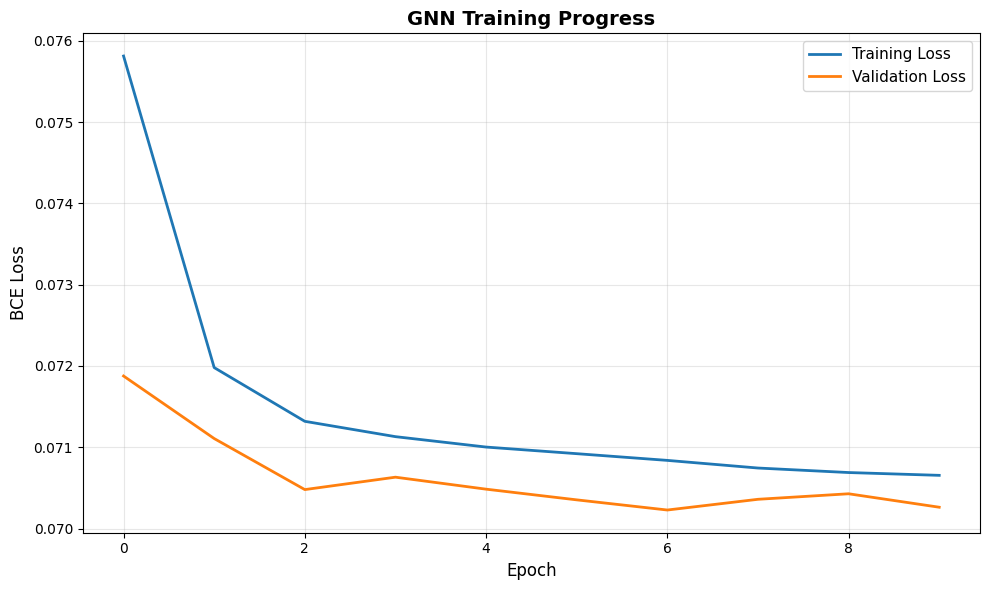

In [ ]:
# Plot training curves
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss', linewidth=2)
plt.plot(val_losses, label='Validation Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('BCE Loss', fontsize=12)
plt.title('GNN Training Progress', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Evaluate GNN Model

Evaluate the GNN model using MRR metric, same as the other models.


In [ ]:
# Create wrapper for evaluation
print("Evaluating GNN Model...")
gnn_wrapper = GNNWrapper(
    model=trained_gnn_model,
    graph_data=graph_data.to(device),
    device=device,
    article_id_to_index=article_id_to_index
)

mrr_gnn = calculate_mrr(
    model=gnn_wrapper,
    X_val=None,
    y_val=y_val,
    query_groups=q_val,
    query_info=query_info_val
)

print("\n" + "="*30)
print(f"   GNN Model MRR: {mrr_gnn:.4f}")
print("="*30)


Evaluating GNN Model...


In [ ]:
print("Calculating Mean Reciprocal Rank (MRR) on validation set...")

# Calculate MRR: for each query (path step), rank all candidates and compute reciprocal rank
# of the correct link. MRR is the average across all queries.
mrr_score = calculate_mrr(
    model=model_poc,
    X_val=X_val_scaled,
    y_val=y_val,
    query_groups=q_val
)

print("\n" + "="*30)
print(f"   Mean Reciprocal Rank (MRR): {mrr_score:.4f}")
print("="*30)

Calculating Mean Reciprocal Rank (MRR) on validation set...

   Mean Reciprocal Rank (MRR): 0.4556
